# Train LightGB

### Imports

In [9]:
import pandas as pd
import numpy as np
from datetime import date
from pathlib import Path
import os
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

%matplotlib inline
import matplotlib.pyplot as plt

import seaborn as sns

from add_features import add_features

### Global variables

In [2]:
root = Path(os.getcwd()).parent.parent
DATA_PATH = os.path.join(root, "data")
DATASET_PATH = os.path.join(DATA_PATH, "check.csv")

TARGET = "NbPaxTotal"

LIMIT_DATE_TRAIN = pd.Timestamp("2025-12-31")
LIMIT_DATE_VALID = pd.Timestamp("2026-01-30")

### Load and prepare data

In [3]:
df = pd.read_csv(DATASET_PATH)
df['LTScheduledDatetime'] = pd.to_datetime(df['LTScheduledDatetime'])
df = df.drop(columns=["OccupancyRate"])

# df = add_features(df)

train_df = df[df['LTScheduledDatetime'] < LIMIT_DATE_TRAIN].copy()
valid_df = df[(df['LTScheduledDatetime'] >= LIMIT_DATE_TRAIN) & (df['LTScheduledDatetime'] < LIMIT_DATE_VALID)].copy()

print(f"Train set: {len(train_df)} rows / From {train_df['LTScheduledDatetime'].min()} to {train_df['LTScheduledDatetime'].max()}")
print(f"Valid set: {len(valid_df)} rows / From {valid_df['LTScheduledDatetime'].min()} to {valid_df['LTScheduledDatetime'].max()}")

X_train = train_df.drop(columns=[TARGET, "LTScheduledDatetime"])
y_train = train_df[TARGET]
X_valid = valid_df.drop(columns=[TARGET, "LTScheduledDatetime"])
y_valid = valid_df[TARGET]

for col in X_train.select_dtypes(include=['object']).columns:
    X_train[col] = X_train[col].astype('category')
    X_valid[col] = X_valid[col].astype('category')


Train set: 286753 rows / From 2023-01-01 00:05:00 to 2025-12-30 23:55:00
Valid set: 7348 rows / From 2025-12-31 00:20:00 to 2026-01-29 23:45:00


### Training model

In [4]:
model = lgb.LGBMRegressor(
    objective="regression",      
    n_estimators=500,      
    learning_rate=0.01,
    num_leaves=60,               
    min_child_samples=5,
    feature_fraction=0.8,
    random_state=42,
    verbose=-1
)

model.fit(
    X_train, y_train,         
    eval_set=[(X_valid, y_valid)], 
    eval_metric="mae",
    callbacks=[lgb.early_stopping(100)]
)

Training until validation scores don't improve for 100 rounds
Did not meet early stopping. Best iteration is:
[500]	valid_0's l1: 14.5985	valid_0's l2: 496.61


,boosting_type,'gbdt'
,num_leaves,60
,max_depth,-1
,learning_rate,0.01
,n_estimators,500
,subsample_for_bin,200000
,objective,'regression'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,5


### Prediction and Evaluation

In [5]:
predictions = model.predict(X_valid)
predictions = np.maximum(0, predictions)

mae = mean_absolute_error(y_valid, predictions)
r2 = r2_score(y_valid, predictions)
rmse = root_mean_squared_error(y_valid, predictions)

print(f"\n── RÉSULTATS FINAUX ──")
print(f"   MAE : {mae:.2f} passengers")    
print(f"   R²  : {r2:.4f}")
print(f"   RMSE : {rmse:.2f}")


── RÉSULTATS FINAUX ──
   MAE : 14.60 passengers
   R²  : 0.8886
   RMSE : 22.28


### Analysis

#### 1. Feature importance

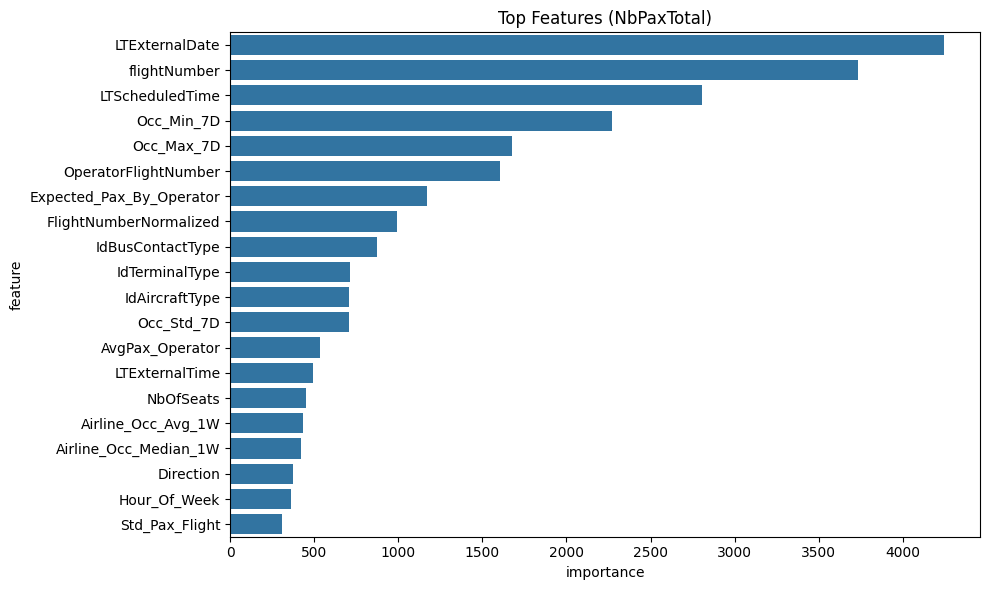

In [11]:
importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model.feature_importances_
}).sort_values(by="importance", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x="importance", y="feature", data=importance.head(20))
plt.title("Top Features (NbPaxTotal)")
plt.tight_layout()
plt.show()

#### 2. Prediction VS Reality

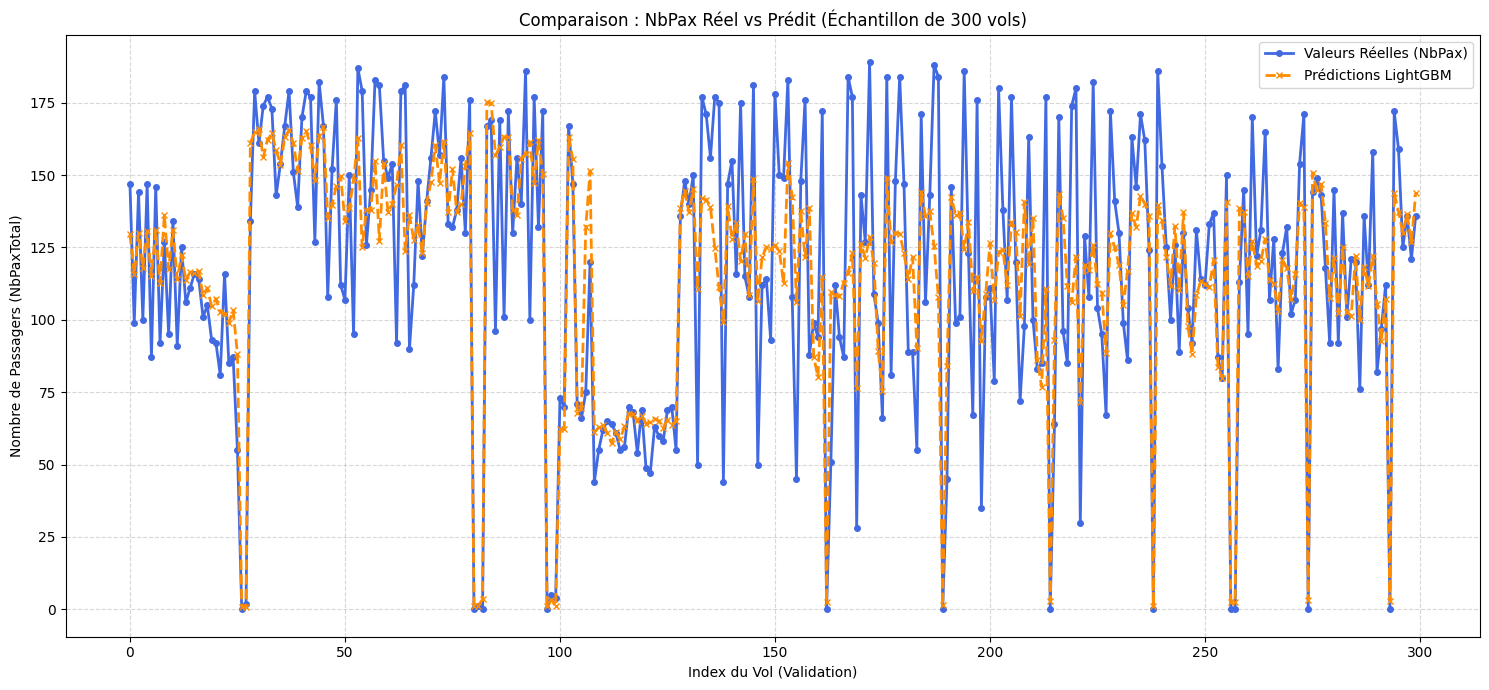

In [12]:
n_sample = 300 
plt.figure(figsize=(15, 7))
plt.plot(y_valid.values[:n_sample], label='Valeurs Réelles (NbPax)', color='royalblue', linewidth=2, marker='o', markersize=4)
plt.plot(predictions[:n_sample], label='Prédictions LightGBM', color='darkorange', linestyle='--', linewidth=2, marker='x', markersize=5)
plt.title(f'Comparaison : NbPax Réel vs Prédit (Échantillon de {n_sample} vols)')
plt.ylabel('Nombre de Passagers (NbPaxTotal)')
plt.xlabel('Index du Vol (Validation)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

#### 3. TOP 10 Errors

In [13]:
analysis_df = valid_df.copy()
analysis_df['Predicted_NbPax'] = predictions
analysis_df['Abs_Error'] = np.abs(analysis_df[TARGET] - analysis_df['Predicted_NbPax'])
top_errors = analysis_df.sort_values(by='Abs_Error', ascending=False).head(10)

columns_to_show = ["IdMovement","FlightNumberNormalized",'LTScheduledDatetime', TARGET, 'Predicted_NbPax', "NbOfSeats", 'Abs_Error']

top_errors_display = top_errors[columns_to_show].copy()
top_errors_display['Predicted_NbPax'] = top_errors_display['Predicted_NbPax'].round(1)
top_errors_display['Abs_Error'] = top_errors_display['Abs_Error'].round(1)

print(top_errors_display.to_string(index=False))

         IdMovement FlightNumberNormalized LTScheduledDatetime  NbPaxTotal  Predicted_NbPax  NbOfSeats  Abs_Error
20260104233900ECNOG               SVA02551 2026-01-04 19:20:00         0.0            185.8      295.0      185.8
20260117152700SERTS               NSZ09713 2026-01-17 16:15:00         0.0            171.3      189.0      171.3
20260109081700FGSPZ               AFR00327 2026-01-09 08:40:00         0.0            163.8      400.0      163.8
                NaN               EJU08435 2026-01-04 18:50:00         0.0            163.6      180.0      163.6
                NaN               EJU04307 2026-01-04 14:35:00         0.0            162.9      180.0      162.9
                NaN               DLH01076 2026-01-03 14:15:00       162.0              2.6      180.0      159.4
20260110144400OYRCM               FLI07026 2026-01-10 15:20:00         0.0            157.5      174.0      157.5
20260117105100SERTI               NSZ09621 2026-01-17 11:15:00         0.0            15